Dataset Shape: (30, 3) records


C:\Python313\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(
C:\Python313\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(



--- KNN Predictions Comparison ---
 Exercise Hours  Daily Steps Prediction (K=3) Prediction (K=5)
            0.5       3000.0          Not Fit          Not Fit
            3.5      11500.0              Fit              Fit
            1.0       5000.0          Not Fit          Not Fit
            4.0      12000.0              Fit              Fit
            2.0       7500.0              Fit              Fit


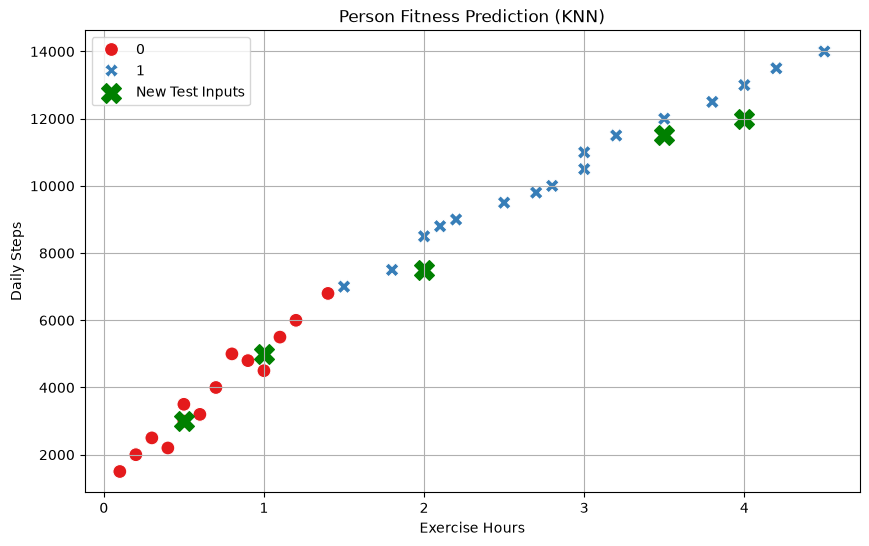

In [1]:
import numpy as np
import pandas as pd
from sklearn.neighbors import KNeighborsClassifier
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Create a dataset with 30 records
# Features: Exercise Hours, Daily Steps
# Target: Fit (1) = Yes, Not Fit (0) = No
data = {
    "exercise_hours": [0.5, 1.0, 0.2, 2.5, 3.0, 0.8, 1.5, 4.0, 0.3, 2.0,
                       3.5, 0.1, 1.2, 2.8, 0.5, 4.5, 1.8, 0.4, 3.2, 2.2,
                       0.9, 3.8, 1.1, 0.6, 2.7, 4.2, 1.4, 0.7, 3.0, 2.1],
    "daily_steps":    [3000, 4500, 2000, 9500, 11000, 5000, 7000, 13000, 25000 if False else 2500, 8500,
                       12000, 1500, 6000, 10000, 3500, 14000, 7500, 2200, 11500, 9000,
                       4800, 12500, 5500, 3200, 9800, 13500, 6800, 4000, 10500, 8800],
    "fit":            [0, 0, 0, 1, 1, 0, 1, 1, 0, 1,
                       1, 0, 0, 1, 0, 1, 1, 0, 1, 1,
                       0, 1, 0, 0, 1, 1, 0, 0, 1, 1]
}

df = pd.DataFrame(data)
print(f"Dataset Shape: {df.shape} records")

# Split features (X) and target (y)
X = df[["exercise_hours", "daily_steps"]]
y = df["fit"]

# 2. Define 5 new inputs (Mix of positive/fit and negative/not fit expectations)
# Format: [Exercise Hours, Daily Steps]
new_inputs = np.array([
    [0.5, 3000],   # Expected: Not Fit (0)
    [3.5, 11500],  # Expected: Fit (1)
    [1.0, 5000],   # Expected: Not Fit / Borderline (0)
    [4.0, 12000],  # Expected: Fit (1)
    [2.0, 7500]    # Expected: Borderline
])

# 3. Run KNN with K = 3 and K = 5
knn_3 = KNeighborsClassifier(n_neighbors=3)
knn_3.fit(X, y)
pred_k3 = knn_3.predict(new_inputs)

knn_5 = KNeighborsClassifier(n_neighbors=5)
knn_5.fit(X, y)
pred_k5 = knn_5.predict(new_inputs)

# 4. Display Results
results_df = pd.DataFrame({
    "Exercise Hours": new_inputs[:, 0],
    "Daily Steps": new_inputs[:, 1],
    "Prediction (K=3)": ["Fit" if p == 1 else "Not Fit" for p in pred_k3],
    "Prediction (K=5)": ["Fit" if p == 1 else "Not Fit" for p in pred_k5]
})

print("\n--- KNN Predictions Comparison ---")
print(results_df.to_string(index=False))

# 5. Visualization
plt.figure(figsize=(10, 6))
sns.scatterplot(x='exercise_hours', y='daily_steps', hue='fit', data=df, palette='Set1', s=100, style='fit')

# Plot new inputs
plt.scatter(new_inputs[:, 0], new_inputs[:, 1], color='green', marker='X', s=200, label='New Test Inputs')

plt.title("Person Fitness Prediction (KNN)")
plt.xlabel("Exercise Hours")
plt.ylabel("Daily Steps")
plt.grid(True)
plt.legend()
plt.show()